# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 03: Análise Exploratória de Dados (EDA)**</font>

## <font color='cyan'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA _PRESENCIALMENTE_ COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br), EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora  |
|-------------------------------|---------------|-------|
| Matheus Botelho Sampaio Netto | Segunda-feira | <font color='cyan'>13:30</font> |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font> |
| Matheus Botelho Sampaio Netto | Quarta-feira  | <font color='cyan'>13:30</font> |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font> |
| Matheus Botelho Sampaio Netto | Sexta-feira   | <font color='cyan'>13:30</font> |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='cyan'>ciano</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratório` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_02_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='cyan'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: data de criação, domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.
- #### <font color='cyan'>S., B. & Nagapadma, R. (2023). RT-IoT2022. UCI Machine Learning Repository. https://doi.org/10.24432/C5P338.</font>

Criado em 01/04/2024, este dataset é focado em segurança de redes IoT. Ele foi desenvolvido para ajudar no treinamento e na validação de sistemas de detecção de intrusão (IDS). O conjunto de dados abrange informações fundamentais, como identificadores de conexão, estatísticas de tráfego, flags de controle(como ACK) e características gerais da carga de dados.

## <font color='green'>Preparação</font>

In [4]:
!pip install pandas ucimlrepo

In [5]:
import pandas as pd

from pprint import pprint
from ucimlrepo import fetch_ucirepo

ds = fetch_ucirepo(id=942)

In [6]:
pprint(ds.metadata)

{'abstract': 'The RT-IoT2022, a proprietary dataset derived from a real-time '
             'IoT infrastructure, is introduced as a comprehensive resource '
             'integrating a diverse range of IoT devices and sophisticated '
             'network attack methodologies. This dataset encompasses both '
             'normal and adversarial network behaviours, providing a general '
             'representation of real-world scenarios.\n'
             'Incorporating data from IoT devices such as ThingSpeak-LED, '
             'Wipro-Bulb, and MQTT-Temp, as well as simulated attack scenarios '
             'involving Brute-Force SSH attacks, DDoS attacks using Hping and '
             'Slowloris, and Nmap patterns, RT-IoT2022 offers a detailed '
             'perspective on the complex nature of network traffic. The '
             'bidirectional attributes of network traffic are meticulously '
             'captured using the Zeek network monitoring tool and the '
             'Flowm

In [7]:
ds.variables

,name,role,type,demographic,description,units,missing_values
0,id.orig_p,Feature,Integer,None,None,None,no
1,id.resp_p,Feature,Integer,None,None,None,no
2,proto,Feature,Categorical,None,None,None,no
3,service,Feature,Continuous,None,None,None,no
4,flow_duration,Feature,Continuous,None,None,None,no
...,...,...,...,...,...,...,...
80,fwd_init_window_size,Feature,Integer,None,None,None,no
81,bwd_init_window_size,Feature,Integer,None,None,None,no
82,fwd_last_window_size,Feature,Integer,None,None,None,no
83,Attack_type,Target,Categorical,None,None,None,no


In [8]:
X = ds.data.features
y = ds.data.targets

df = pd.concat([X, y], axis='columns')

df

,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,0.0,29729182.96,29729182.96,29729182.96,29729182.96,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,0.0,29855277.06,29855277.06,29855277.06,29855277.06,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,0.0,29842149.02,29842149.02,29842149.02,29842149.02,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,0.0,29913774.97,29913774.97,29913774.97,29913774.97,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,0.0,29814704.90,29814704.90,29814704.90,29814704.90,0.0,64240,26847,502,MQTT_Publish
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123112,59247,63331,tcp,-,0.000006,1,1,0,0,167772.160000,...,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123113,59247,64623,tcp,-,0.000007,1,1,0,0,144631.172400,...,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123114,59247,64680,tcp,-,0.000006,1,1,0,0,167772.160000,...,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123115,59247,65000,tcp,-,0.000006,1,1,0,0,167772.160000,...,0.0,0.00,0.00,0.00,0.00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN


## <font color='green'>**2.1 Conjuntos de Dados**</font>

### <font color='cyan'>Q1: Exiba 10 amostras aleatórias do conjunto de dados.</font>

In [9]:
print(df.sample(10))

        id.orig_p  id.resp_p proto service  flow_duration  fwd_pkts_tot  \
7752        40942         80   tcp    http       0.740489             7   
32356       14407         21   tcp       -       0.000005             1   
104670      55125         21   tcp       -       0.000002             1   
47376       29496         21   tcp       -       0.000001             1   
51877       33999         21   tcp       -       0.000004             1   
45490       27542         21   tcp       -       0.000004             1   
80161        6025         21   tcp       -       0.000005             1   
115680      46600         33   tcp       -       0.000007             1   
89327       60074         21   tcp       -       0.000003             1   
84147       16363         21   tcp       -       0.000001             1   

        bwd_pkts_tot  fwd_data_pkts_tot  bwd_data_pkts_tot  fwd_pkts_per_sec  \
7752               5                  2                  1      9.453213e+00   
32356         

### <font color='cyan'>Q2: Quantas amostras o conjunto de dados possui?</font>

In [10]:
print(f"A quantidade total de amostras é igual a {len(df)}") # Também poderiamos usar print(df.shape[0]) que teríamos o mesmo resultado.

A quantidade total de amostras é igual a 123117


### <font color='cyan'>Q3: Quantas características o conjunto de dados possui?</font>

In [11]:
print(f"A quantidade total de características é igual a {len(df.columns)}") # Também poderíamos usar print(df.shape[1]) que teríamos o mesmo resultado.

A quantidade total de características é igual a 84


### <font color='cyan'>Q4: O conjunto de dados possui características numéricas? Se sim, escreva seu(s) nome(s) e classifique-a(s) como contínua(s) e/ou discreta(s).</font>
- #### <font color='cyan'>Observação: considere que uma caraterística numérica é discreta se possui menos que 50 valores únicos.</font>

In [12]:
num_cols = df.select_dtypes(include="number").columns # apenas colunas numéricas
print(f"As colunas numéricas são: {num_cols}") # Comprova que sim, há variáveis numéricas

# Classificação em Discretas e Contínuas:
for col in num_cols:
    if df[col].nunique() < 50:
        print(f"{col} é discreta")
    else:
        print(f"{col} é contínua")

As colunas numéricas são: Index(['id.orig_p', 'id.resp_p', 'flow_duration', 'fwd_pkts_tot',
       'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot',
       'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec',
       'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min',
       'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min',
       'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count',
       'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count',
       'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count',
       'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min',
       'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg',
       'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max',
       'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std',
       'flow_pkts_payload.min', 'flow_pkts_payload.max',
       'flow_pkts_payload.tot', 'f

### <font color='cyan'>Q5: O conjunto de dados possui características categóricas? Se sim, escreva seu(s) nome(s) e sua(s) quantidade(s) de valores únicos.</font>

In [13]:
cat_cols = df.select_dtypes(include="object").columns # Apenas características categóricas
print(f"As colunas categóricas são: {cat_cols}") # Comprovação de que sim

# Quantidade de valores únicos para as variáveis categóricas:
print(f"A quantidade de valores únicos são de: {df[cat_cols].nunique()}")

As colunas categóricas são: Index(['proto', 'service', 'Attack_type'], dtype='object')
A quantidade de valores únicos são de: proto           3
service        10
Attack_type    12
dtype: int64


## <font color='green'>**2.2 Estatística Descritiva Básica**</font>

### <font color='cyan'> Q6: Escolha uma característica numérica do conjunto de dados. Escreva seu nome a seguir.</font>

A característica escolhida é 'flow duration'.

### <font color='cyan'> Q7: Calcule e mostre suas Medidas de Tendência Central (média, mediana e moda).</font>

In [14]:
print(f"A média é igual a {df['flow_duration'].mean():.6f}s")
print(f"A mediana é igual a {df['flow_duration'].median():.6f}s")
print(f"A moda é igual a {df['flow_duration'].mode()[0]:.6f}s") # Se não colocar [0], ele dá duas modas diferentes (0s e 0.000004s).

A média é igual a 3.809566s
A mediana é igual a 0.000004s
A moda é igual a 0.000004s


### <font color='cyan'> Q8: Calcule e mostre suas Medidas de Dispersão (mínimo, máximo e amplitude).</font>

In [15]:
print(df['flow_duration'].describe()) # Como mostrado em sala, mostra muitas informações relevantes sobre uma coluna.
# ou
print(f"O mínimo é igual a {df['flow_duration'].min():.6f}s")
print(f"O máximo é igual a {df['flow_duration'].max():.6f}s")
print(f"A amplitude é igual a {df['flow_duration'].max() - df['flow_duration'].min():.6f}s")

count    123117.000000
mean          3.809566
std         130.005408
min           0.000000
25%           0.000001
50%           0.000004
75%           0.000005
max       21728.335580
Name: flow_duration, dtype: float64
O mínimo é igual a 0.000000s
O máximo é igual a 21728.335580s
A amplitude é igual a 21728.335580s


## <font color='green'>**2.3 Análise Univariada**</font>

### <font color='cyan'> Q9: Escolha uma característica categórica do conjunto de dados. Escreva seu nome a seguir.</font>

A características escolhida foi: "Attack_type"

### <font color='cyan'> Q10: Crie e exiba uma Tabela de Frequência e/ou um Gráfico de Barras para a característica escolhida.</font>

In [16]:
!pip install matplotlib # Instalando o matplotlib para exibir o gráfico

Text(0, 0.5, 'Quantity')

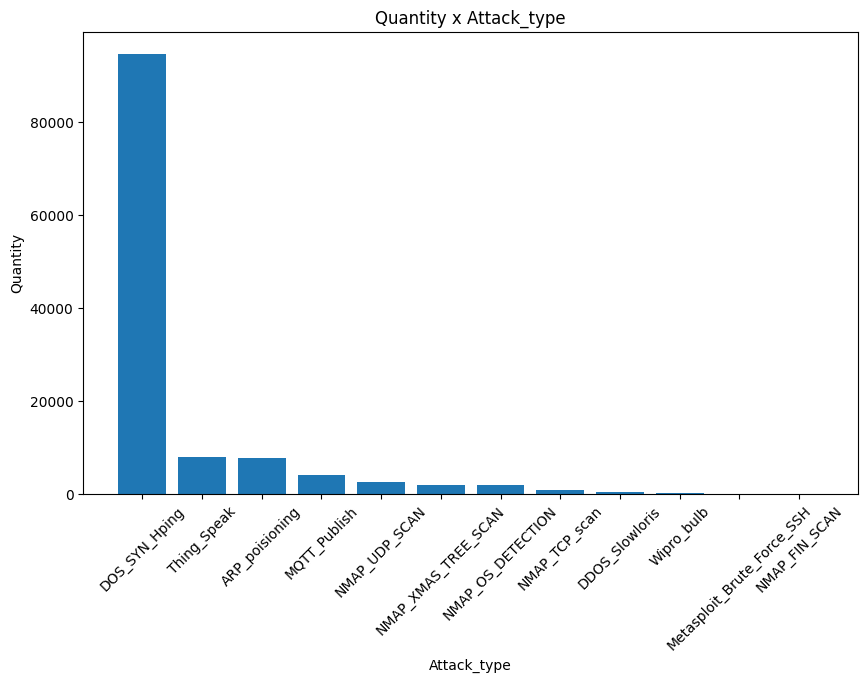

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(df['Attack_type'].value_counts().index, df['Attack_type'].value_counts())
plt.title('Quantity x Attack_type')
plt.xlabel('Attack_type')
plt.xticks(rotation=45)
plt.ylabel('Quantity')

### <font color='cyan'> Q11: Escolha uma característica numérica do conjunto de dados. Escreva seu nome a seguir.</font>

A característica escolhida foi: 'fwd_pkts_payload.avg' - média do tamanho da carga útil dos pacotes enviados

### <font color='cyan'> Q13: Crie e exiba um Histograma e/ou uma Estimativa de Densidade por Kernel (KDE) para a característica escolhida.</font>

In [18]:
!pip install seaborn # Instalando o seaborn para exibir o gráfico KDE

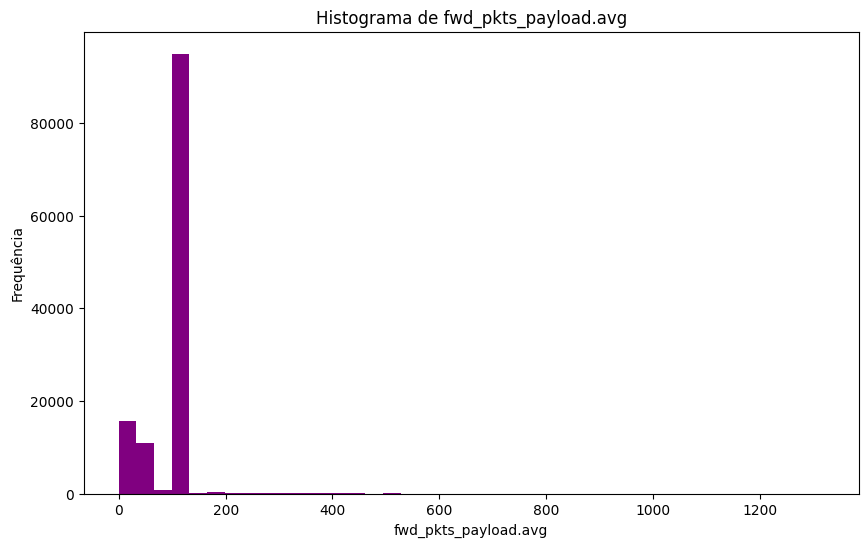

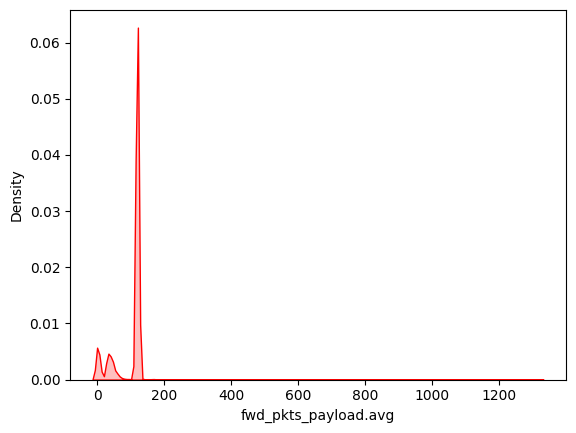

In [19]:
import seaborn as sns
plt.figure(figsize=(10, 6))
plt.hist(df['fwd_pkts_payload.avg'], bins=40, color='purple')
plt.title('Histograma de fwd_pkts_payload.avg')
plt.xlabel('fwd_pkts_payload.avg')
plt.ylabel('Frequência')
plt.show()

sns.kdeplot(x='fwd_pkts_payload.avg', data=df, fill = True, color='red') # Estimativa de Densidade por Kernel (KDE)
plt.show()

## <font color='green'>**2.4 Análise Bivariada**</font>

### <font color='cyan'> Q14: Escolha duas características do conjuntos de dados. Escreva seus nome a seguir.</font>

As características escolhidas foram: 'Attack_type'(categórica) e 'flow_pkts_per_sec'(numérica).

### <font color='cyan'>Q15: De acordo com os tipos das características escolhidas, produza pelo menos uma visualização de análise bivariada. Exemplos:</font>
- ### <font color='cyan'>Numérica vs Numérica: Scatter Plot ou Hexbin Plot;</font>
- ### <font color='cyan'>Categórica vs Numérica: Box Plot ou Violin Plot;</font>
- ### <font color='cyan'>Categórica vs Categórica: Crosstab, Grouped Bar Chart ou Stacked Bar Chart.</font>

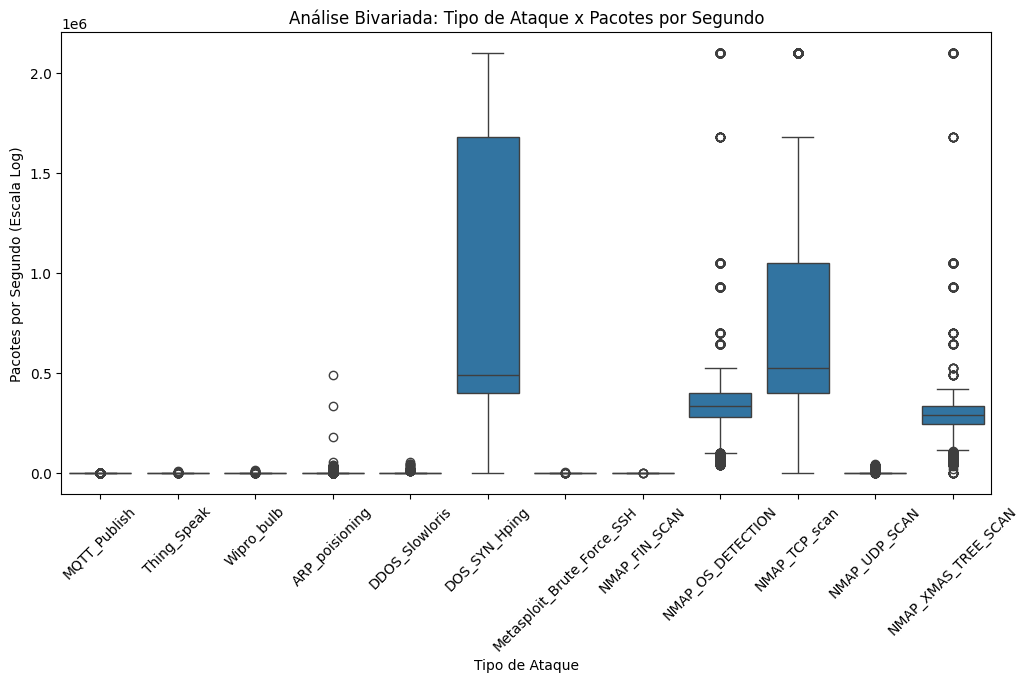

In [20]:
plt.figure(figsize=(12, 6))

sns.boxplot(x='Attack_type', y='flow_pkts_per_sec', data=df)

plt.xticks(rotation=45) # Única forma que encontrei para deixar legível

plt.title('Análise Bivariada: Tipo de Ataque x Pacotes por Segundo')
plt.xlabel('Tipo de Ataque')
plt.ylabel('Pacotes por Segundo (Escala Log)')

plt.show()

## <font color='green'>**2.5 Identificação de Problemas nos Dados**</font>

### <font color='cyan'> Q16: Inspecione o conjuntos de dados para verificar se há:</font>
- #### <font color='cyan'> Dados Ausentes;</font>
- #### <font color='cyan'> Valores Atípicos (Outliers);</font>
- #### <font color='cyan'> Valores Duplicados;</font>
### <font color='cyan'> Reporte sua(s) descoberta(s) a seguir.</font>

In [21]:
# Fazendo a análise de Dados Ausentes:
print(f"A quantidade de dados ausentes é igual a {df.isnull().sum().sum()}") # Apenas um sum mostra a coluna nula

# Fazendo a análise de Outliers:
# Podemos utilizar a num_cols de anteriormente + IQR aprendido em aula

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_por_coluna = ((df[num_cols] < lim_inf) | (df[num_cols] > lim_sup)).sum()

print("Quantidade de outliers por característica:")
print(outliers_por_coluna[outliers_por_coluna > 0]) # Mostra apenas colunas que têm outliers

# Fazendo a análise de duplicatas:
print(f"A quantidade de duplicatas é igual a {df.duplicated().sum()}")

A quantidade de dados ausentes é igual a 0
Quantidade de outliers por característica:
id.resp_p               28452
flow_duration           19171
fwd_pkts_tot            17662
bwd_pkts_tot            32364
fwd_data_pkts_tot       24161
                        ...  
idle.avg                 5697
idle.std                 1017
fwd_init_window_size    28458
bwd_init_window_size    10359
fwd_last_window_size    28458
Length: 75, dtype: int64
A quantidade de duplicatas é igual a 5195


### <font color='cyan'> Q17: Caso problemas tenham sido encontrados, proponha soluções para eles.</font>
### <font color='cyan'> Exiba o conjunto de dados antes e depois de aplicar as soluções, enfatizando as mudanças.</font>

In [22]:
# Como não houve problemas com valores nulos, não há necessidade de tratamento dos dados nesse sentido.

# Duplicatas Antes:

print(f"A quantidade de duplicatas é igual a {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)

print(f"Duplicatas depois: {df.duplicated().sum()}")

# Printando o DataFrame após essa modificação:

print("\n")
print("-------")
print(df)
print("-------")
print("\n")

# Dados sem tratamento de outliers:
# Quantidade de outliers:
print("Quantidade de outliers por característica:")
print(outliers_por_coluna[outliers_por_coluna > 0])

# Tratamento de Outliers
df_sem_outliers = df[(df[num_cols] >= lim_inf) & (df[num_cols] <= lim_sup)]
print("\n")
print("-------")
print(df_sem_outliers)
print("-------")
print("\n")
# Verificação de Outliers Restantes
outliers_restantes = ((df_sem_outliers[num_cols] < lim_inf) | (df_sem_outliers[num_cols] > lim_sup)).sum()
print("Outliers após tratamento:")
print(outliers_restantes[outliers_restantes > 0])

# Podemos ver que nesse caso, ao eliminar os outliers, as duplicatas também foram removidas.

# Dataframe final Corrigido:

A quantidade de duplicatas é igual a 5195
Duplicatas depois: 0


-------
        id.orig_p  id.resp_p proto service  flow_duration  fwd_pkts_tot  \
0           38667       1883   tcp    mqtt      32.011598             9   
1           51143       1883   tcp    mqtt      31.883584             9   
2           44761       1883   tcp    mqtt      32.124053             9   
3           60893       1883   tcp    mqtt      31.961063             9   
4           51087       1883   tcp    mqtt      31.902362             9   
...           ...        ...   ...     ...            ...           ...   
123112      59247      63331   tcp       -       0.000006             1   
123113      59247      64623   tcp       -       0.000007             1   
123114      59247      64680   tcp       -       0.000006             1   
123115      59247      65000   tcp       -       0.000006             1   
123116      59247      65129   tcp       -       0.000006             1   

        bwd_pkts_tot  fwd_

## <font color='green'>**2.6 Correlação Simples**</font>

### <font color='cyan'> Q18: Escolha duas características numéricas do conjuntos de dados. Escreva seus nomes a seguir.</font>

As características escolhidas foram: 'fwd_pkts_tot' e 'fwd_data_pkts_tot'.

### <font color='cyan'> Q19: Calcule e exiba o Coeficiente de Correlação de Pearson ($r$) entre elas.</font>

In [23]:
# Calculando o coeficiente de Pearson entre as características:
corr = df['fwd_pkts_tot'].corr(df['fwd_data_pkts_tot'])

print(f"O coeficiente de correlação de Pearson é: {corr:.6f}")

O coeficiente de correlação de Pearson é: 0.909437


### <font color='cyan'> Q20: Interprete o coeficiente de correlação, em termos de sinal e magnitude.</font>

Como o valor do coeficiente de Pearson foi perto de 1 (magnitude), isso indica que muito provavelmente essas características são bem correlacionadas (diretamente proporcionais - sinal positivo).